In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
sys.path.append("/extdata4/baeklab/Hyeonseo/m6A/modformer")
from utils.utils import printmessage
import glob
import tqdm


In [2]:
ivt_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A_ON0118-20241129-120647-8-182000-token_normalise_ver161024_ON0105_m6Afinal/pileup_strid.genomic.pkl"
ivt_df = pd.read_pickle(ivt_df)
ivt_df = ivt_df[ivt_df["count_all"]>=20]
print(ivt_df)

                       genome_id gene_symbol  coding  isoforms      pm6a  \
genome_id                                                                  
chr10:+:1000681  chr10:+:1000681      GTPBP4    True         1 -0.000000   
chr10:+:1000683  chr10:+:1000683      GTPBP4    True         1  0.097608   
chr10:+:1000685  chr10:+:1000685      GTPBP4    True         1  0.051422   
chr10:+:1000694  chr10:+:1000694      GTPBP4    True         1  0.029605   
chr10:+:1000701  chr10:+:1000701      GTPBP4    True         1  0.025141   
...                          ...         ...     ...       ...       ...   
chrX:-:8531045    chrX:-:8531045       ANOS1    True         1 -0.000000   
chrX:-:8531047    chrX:-:8531047       ANOS1    True         1 -0.000000   
chrX:-:8531050    chrX:-:8531050       ANOS1    True         1  0.000000   
chrX:-:8531054    chrX:-:8531054       ANOS1    True         1 -0.000000   
chrX:-:8531058    chrX:-:8531058       ANOS1    True         1  0.000000   

           

In [3]:
hek_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A_ON0118-20241129-120647-8-182000-token_normalise_ver161024_ON0090_m6Afinal/pileup_strid.genomic.pkl"
hek_df = pd.read_pickle(hek_df)
hek_df = hek_df[hek_df["count_all"]>=20]
print(hek_df)

                       genome_id gene_symbol  coding  isoforms      pm6a  \
genome_id                                                                  
chr10:+:1000681  chr10:+:1000681      GTPBP4    True         1 -0.000000   
chr10:+:1000683  chr10:+:1000683      GTPBP4    True         1  0.008392   
chr10:+:1000685  chr10:+:1000685      GTPBP4    True         1  0.007436   
chr10:+:1000694  chr10:+:1000694      GTPBP4    True         1 -0.000000   
chr10:+:1000701  chr10:+:1000701      GTPBP4    True         1  0.016405   
...                          ...         ...     ...       ...       ...   
chrX:-:8732088    chrX:-:8732088       ANOS1    True         1  0.000000   
chrX:-:8732091    chrX:-:8732091       ANOS1    True         1 -0.000000   
chrX:-:8732104    chrX:-:8732104       ANOS1    True         1  0.039769   
chrX:-:8732109    chrX:-:8732109       ANOS1    True         1 -0.000000   
chrX:-:8732112    chrX:-:8732112       ANOS1    True         1  0.048285   

           

In [4]:
hela_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A_ON0118-20241129-120647-8-182000-token_normalise_ver161024_ON0091_m6Afinal/pileup_strid.genomic.pkl"
hela_df = pd.read_pickle(hela_df)
hela_df = hela_df[hela_df["count_all"]>=20]
print(hela_df)

                       genome_id gene_symbol  coding  isoforms      pm6a  \
genome_id                                                                  
chr10:+:1000681  chr10:+:1000681      GTPBP4    True         1  0.013391   
chr10:+:1000683  chr10:+:1000683      GTPBP4    True         1 -0.000000   
chr10:+:1000685  chr10:+:1000685      GTPBP4    True         1 -0.000000   
chr10:+:1000694  chr10:+:1000694      GTPBP4    True         1 -0.000000   
chr10:+:1000701  chr10:+:1000701      GTPBP4    True         1  0.012365   
...                          ...         ...     ...       ...       ...   
chrX:-:8732088    chrX:-:8732088       ANOS1    True         1 -0.000000   
chrX:-:8732091    chrX:-:8732091       ANOS1    True         1  0.064984   
chrX:-:8732104    chrX:-:8732104       ANOS1    True         1 -0.000000   
chrX:-:8732109    chrX:-:8732109       ANOS1    True         1 -0.000000   
chrX:-:8732112    chrX:-:8732112       ANOS1    True         1 -0.000000   

           

In [5]:
hek_df.reset_index(drop=True, inplace=True)
hela_df.reset_index(drop=True, inplace=True)
ivt_df.reset_index(drop=True, inplace=True)

In [6]:
def process_dorado_inferece(data_path):

    if os.path.exists(data_path.replace(".bed", ".pkl")):
        data_df = pd.read_pickle(data_path.replace(".bed", ".pkl"))
        return data_df
    else:
        data_df = pd.read_csv(data_path, quoting = 3, sep = "\t", header = None, dtype=str)
        ## Keep column 0, 1, 4, 9
        data_df = data_df[[0, 1, 4, 9]]
        data_df.columns = ["nmid", "pos", "depth", "pred_dorado"]
        data_df["depth"] = data_df["depth"].astype(int)
        data_df["pred_dorado"] = data_df["pred_dorado"].str.split(" ").str[1].astype(float) / 100
        data_df["label_id"] = data_df["nmid"].str.split(".").str[0] + ":" + data_df["pos"]
        data_df = data_df[["label_id", "pred_dorado","depth"]].copy()
        data_df.rename(columns = {"depth": "dorado_count"}, inplace = True)
        data_df.to_pickle(data_path.replace(".bed", ".pkl"))

        return data_df

In [7]:
dorado_ivt = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0105/ON0105/result/intermediates/dorado_output_notrim_m6a.sorted.pkl.m6A.genomic.pkl")
dorado_ivt = dorado_ivt[dorado_ivt["count_dom"] >= 20]
print(dorado_ivt)

                       genome_id gene_symbol       dom  count_dom  coding
genome_id                                                                
chr10:+:1000681  chr10:+:1000681      GTPBP4  0.029412         34    True
chr10:+:1000683  chr10:+:1000683      GTPBP4  0.000000         38    True
chr10:+:1000685  chr10:+:1000685      GTPBP4  0.000000         39    True
chr10:+:1000694  chr10:+:1000694      GTPBP4  0.000000         41    True
chr10:+:1000701  chr10:+:1000701      GTPBP4  0.000000         37    True
...                          ...         ...       ...        ...     ...
chrX:-:77895411  chrX:-:77895411       MAGT1  0.035714         28    True
chrX:-:77895412  chrX:-:77895412       MAGT1  0.000000         29    True
chrX:-:77895416  chrX:-:77895416       MAGT1  0.000000         27    True
chrX:-:77895419  chrX:-:77895419       MAGT1  0.000000         27    True
chrX:-:77895421  chrX:-:77895421       MAGT1  0.000000         26    True

[1056017 rows x 5 columns]


In [8]:
dorado_mrna = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/dorado-070-aligned/intermediates/dorado_output.pkl.m6A.genomic.pkl")
dorado_mrna = dorado_mrna[dorado_mrna["count_dom"] >= 20]
print(dorado_mrna)

                       genome_id gene_symbol       dom  count_dom  coding
genome_id                                                                
chr10:+:1000681  chr10:+:1000681      GTPBP4  0.004219        474    True
chr10:+:1000683  chr10:+:1000683      GTPBP4  0.004073        491    True
chr10:+:1000685  chr10:+:1000685      GTPBP4  0.017167        466    True
chr10:+:1000694  chr10:+:1000694      GTPBP4  0.006061        495    True
chr10:+:1000701  chr10:+:1000701      GTPBP4  0.002092        478    True
...                          ...         ...       ...        ...     ...
chrX:-:8732091    chrX:-:8732091       ANOS1  0.000000        100    True
chrX:-:8732104    chrX:-:8732104       ANOS1  0.066667         75    True
chrX:-:8732109    chrX:-:8732109       ANOS1  0.000000         96    True
chrX:-:8732112    chrX:-:8732112       ANOS1  0.150685         73    True
chrX:-:8732136    chrX:-:8732136       ANOS1  0.000000         48    True

[10549544 rows x 5 columns]


In [10]:
df_m6anet_ivt = "/extdata4/baeklab/Hyeonseo/m6A/m6anet/old_refseq/ON0105/out/genomic/gene_df.pkl"
df_m6anet_cell = "/extdata4/baeklab/Hyeonseo/m6A/m6anet/old_refseq/ON0090/out/genomic/gene_df.pkl"

df_m6anet_ivt = pd.read_pickle(df_m6anet_ivt)
df_m6anet_cell = pd.read_pickle(df_m6anet_cell)

df_m6anet_ivt = df_m6anet_ivt[df_m6anet_ivt["count_dom"] >= 20]
df_m6anet_cell = df_m6anet_cell[df_m6anet_cell["count_dom"] >= 20]

print(df_m6anet_ivt)
print(df_m6anet_cell)


                       genome_id gene_symbol       dom      pm6a  count_dom  \
genome_id                                                                     
chr10:+:1000683  chr10:+:1000683      GTPBP4  0.000000  0.053607        130   
chr10:+:1000701  chr10:+:1000701      GTPBP4  0.162602  0.338440        123   
chr10:+:1000722  chr10:+:1000722      GTPBP4  0.064000  0.162817        125   
chr10:+:1000831  chr10:+:1000831      GTPBP4  0.103448  0.292391        145   
chr10:+:1000842  chr10:+:1000842      GTPBP4  0.074074  0.191957        135   
...                          ...         ...       ...       ...        ...   
chrX:-:8530670    chrX:-:8530670       ANOS1  0.000000  0.006585         31   
chrX:-:8530819    chrX:-:8530819       ANOS1  0.200000  0.514384         25   
chrX:-:8530830    chrX:-:8530830       ANOS1  0.115385  0.394932         26   
chrX:-:8530974    chrX:-:8530974       ANOS1  0.000000  0.085032         23   
chrX:-:8530991    chrX:-:8530991       ANOS1  0.0000

In [11]:
hek_depth = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/label/BaeklabFinal.Genome.v2Genomic.GP3.depth5_None.twm6astrict.agg.pkl")
count_hek = len(hek_depth[hek_depth["depth"]>=20])
print(count_hek)

10567697


In [12]:
ivt_depth = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0105/ON0105/label/BaeklabFinal.Genome..v2Genomic.GP3.depth5_None.twm6astrict.agg.pkl")
count_ivt = len(ivt_depth[ivt_depth["depth"]>=20])
print(count_ivt)

3956659


In [24]:
def estimate_fdr_fpr(dorado_mrna, dorado_ivt, airna_mrna, airna_ivt, m6anet_mrna, m6anet_ivt):
    threshold = np.arange(0.0, 3.0, 0.01)
    dorado_fdr_list = []
    airna_fdr_list = []
    dorado_fpr_list = []
    airna_fpr_list = []
    m6anet_fdr_list = []
    m6anet_fpr_list = []
    
    dorado_mrna = np.sort(dorado_mrna["dom"].values)
    dorado_ivt = np.sort(dorado_ivt["dom"].values)
    airna_mrna = np.sort(airna_mrna["pm6a"].values)
    airna_ivt = np.sort(airna_ivt["pm6a"].values)
    m6anet_mrna = np.sort(m6anet_mrna["pm6a"].values)
    m6anet_ivt = np.sort(m6anet_ivt["pm6a"].values)
    
    for t in threshold:
        dorado_ivt_positive_frac = np.sum(dorado_ivt >= t) / count_ivt
        dorado_mrna_positive_frac = np.sum(dorado_mrna >= t) / count_hek
        airna_ivt_positive_frac = np.sum(airna_ivt >= t) / count_ivt
        airna_mrna_positive_frac = np.sum(airna_mrna >= t) / count_hek
        m6anet_ivt_positive_frac = np.sum(m6anet_ivt >= t) / count_ivt
        m6anet_mrna_positive_frac = np.sum(m6anet_mrna >= t) / count_hek
        dorado_fdr_list.append(dorado_ivt_positive_frac / dorado_mrna_positive_frac)
        airna_fdr_list.append(airna_ivt_positive_frac / airna_mrna_positive_frac)
        dorado_fpr_list.append(dorado_ivt_positive_frac)
        airna_fpr_list.append(airna_ivt_positive_frac)
        m6anet_fdr_list.append(m6anet_ivt_positive_frac / m6anet_mrna_positive_frac)
        m6anet_fpr_list.append(m6anet_ivt_positive_frac)
        
    df = pd.DataFrame({"dorado_fdr": dorado_fdr_list, "airna_fdr": airna_fdr_list, "dorado_fpr": dorado_fpr_list, "airna_fpr": airna_fpr_list, "threshold": threshold, "m6anet_fdr": m6anet_fdr_list, "m6anet_fpr": m6anet_fpr_list})
    
    return df

In [25]:
df = estimate_fdr_fpr(dorado_mrna, dorado_ivt, hek_df, ivt_df, df_m6anet_cell, df_m6anet_ivt)
df[['dorado_fdr', 'airna_fdr', 'dorado_fpr', 'airna_fpr', 'm6anet_fdr', 'm6anet_fpr']] = np.clip(df[['dorado_fdr', 'airna_fdr', 'dorado_fpr', 'airna_fpr', 'm6anet_fdr', 'm6anet_fpr']], 0, 1)
print(df)

/tmp/ipykernel_236909/866712976.py:28: RuntimeWarning: invalid value encountered in scalar divide
  m6anet_fdr_list.append(m6anet_ivt_positive_frac / m6anet_mrna_positive_frac)
/tmp/ipykernel_236909/866712976.py:24: RuntimeWarning: invalid value encountered in scalar divide
  dorado_fdr_list.append(dorado_ivt_positive_frac / dorado_mrna_positive_frac)


     dorado_fdr  airna_fdr  dorado_fpr  airna_fpr  threshold  m6anet_fdr  \
0      0.267355   0.839051    0.266896   0.832876       0.00    0.700339   
1      0.297754   0.522506    0.147214   0.103139       0.01    0.703246   
2      0.359975   0.550597    0.131000   0.084867       0.02    0.706599   
3      0.410393   0.571055    0.111986   0.070487       0.03    0.710744   
4      0.442989   0.580100    0.092702   0.059062       0.04    0.712230   
..          ...        ...         ...        ...        ...         ...   
295         NaN   0.000000    0.000000   0.000000       2.95         NaN   
296         NaN   0.000000    0.000000   0.000000       2.96         NaN   
297         NaN   0.000000    0.000000   0.000000       2.97         NaN   
298         NaN   0.000000    0.000000   0.000000       2.98         NaN   
299         NaN   0.000000    0.000000   0.000000       2.99         NaN   

     m6anet_fpr  
0      0.028357  
1      0.027692  
2      0.026583  
3      0.025351

In [26]:
plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

Text(0.5, 1.0, 'log FDR vs. Threshold')

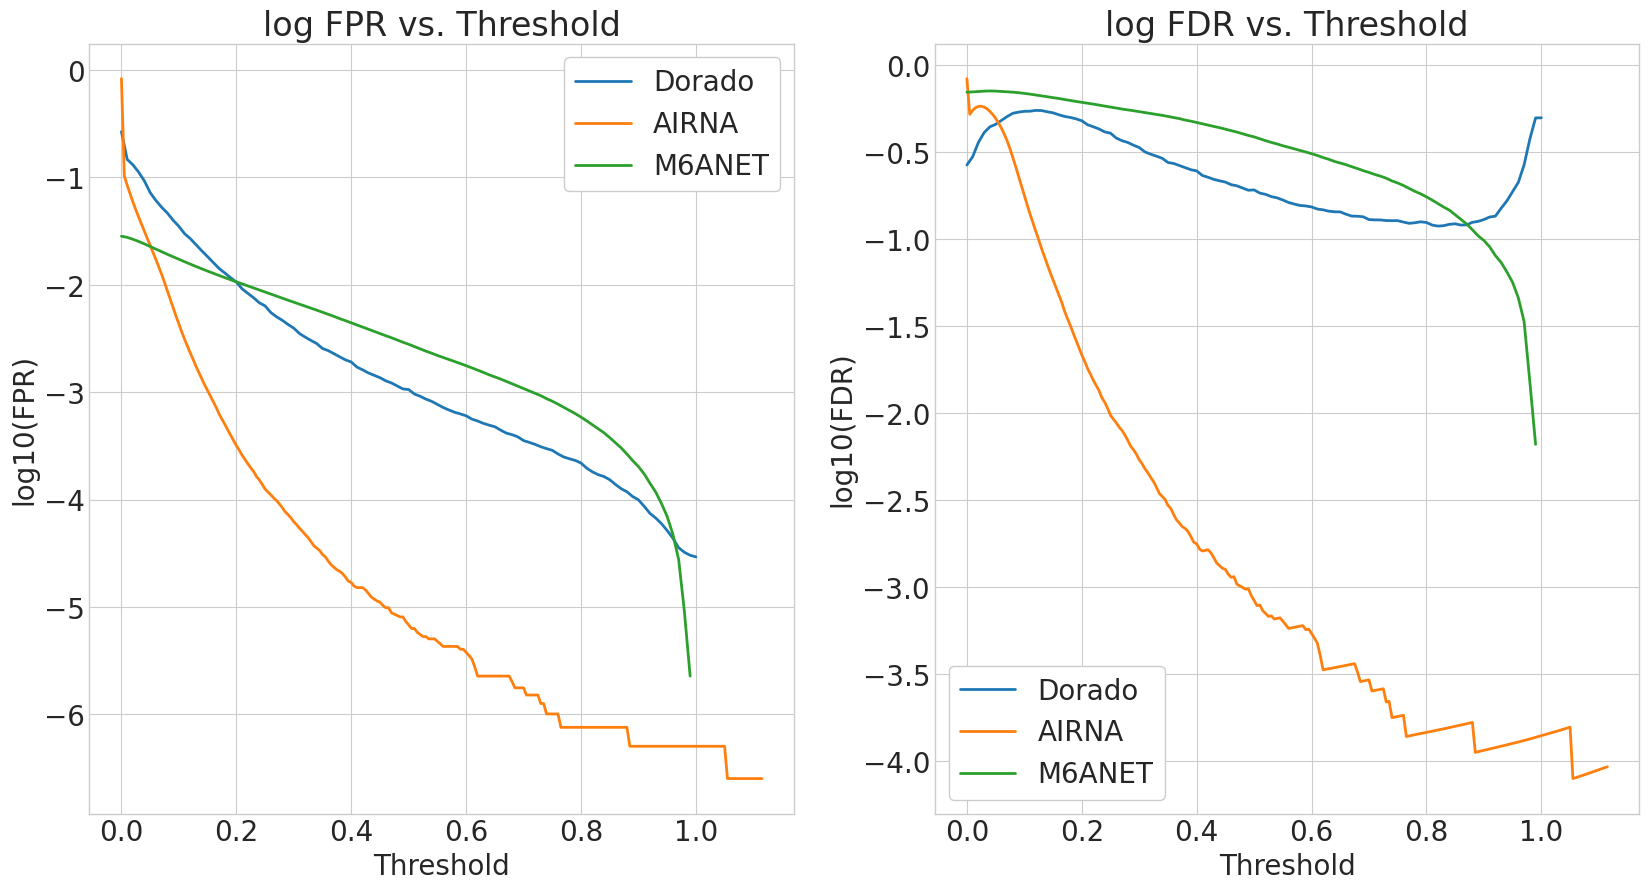

In [28]:

plt.rcParams.update({'font.size': 20})
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

## plot 1. log10(FPR)
axes[0].plot(df["threshold"], np.log10(df["dorado_fpr"]), label = "Dorado")
axes[0].plot(df["threshold"]/2, np.log10(df["airna_fpr"]), label = "AIRNA")
axes[0].plot(df["threshold"], np.log10(df["m6anet_fpr"]), label = "M6ANET")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("log10(FPR)")
axes[0].legend()
axes[0].set_title("log FPR vs. Threshold")

## plot 2. FDR
axes[1].plot(df["threshold"], np.log10(df["dorado_fdr"]), label = "Dorado")
axes[1].plot(df["threshold"]/2, np.log10(df["airna_fdr"] ), label = "AIRNA")
axes[1].plot(df["threshold"], np.log10(df["m6anet_fdr"]), label = "M6ANET")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("log10(FDR)")
axes[1].legend()
axes[1].set_title("log FDR vs. Threshold")




In [16]:
## Find Threshold for 0.05 and 0.01 FDR

thr_005 = df[df["airna_fdr"]<=0.05]["threshold"].min()
thr_001 = df[df["airna_fdr"]<=0.01]["threshold"].min()
thr_0001 = df[df["airna_fdr"]<=0.001]["threshold"].min()

print(thr_005, thr_001, thr_0001)

0.32 0.5 0.96


In [17]:
df = estimate_fdr_fpr(dorado_mrna, dorado_ivt, hela_df, ivt_df)

thr_005 = df[df["airna_fdr"]<=0.05]["threshold"].min()
thr_001 = df[df["airna_fdr"]<=0.01]["threshold"].min()
thr_0001 = df[df["airna_fdr"]<=0.001]["threshold"].min()

print(thr_005, thr_001, thr_0001)

/tmp/ipykernel_236909/1372065612.py:17: RuntimeWarning: invalid value encountered in scalar divide
  dorado_fdr_list.append(dorado_ivt_positive_frac / dorado_mrna_positive_frac)


0.34 0.53 1.0


In [18]:
ivt_count = len(ivt_df)
mrna_count = len(hek_df)

In [19]:
print(ivt_count)
print(len(dorado_ivt))

3295406
1056017


In [20]:
print(df_m6anet_ivt)

                       genome_id gene_symbol       dom      pm6a  count_dom  \
genome_id                                                                     
chr10:+:1000683  chr10:+:1000683      GTPBP4  0.000000  0.053607        130   
chr10:+:1000701  chr10:+:1000701      GTPBP4  0.162602  0.338440        123   
chr10:+:1000722  chr10:+:1000722      GTPBP4  0.064000  0.162817        125   
chr10:+:1000831  chr10:+:1000831      GTPBP4  0.103448  0.292391        145   
chr10:+:1000842  chr10:+:1000842      GTPBP4  0.074074  0.191957        135   
...                          ...         ...       ...       ...        ...   
chrX:-:8530670    chrX:-:8530670       ANOS1  0.000000  0.006585         31   
chrX:-:8530819    chrX:-:8530819       ANOS1  0.200000  0.514384         25   
chrX:-:8530830    chrX:-:8530830       ANOS1  0.115385  0.394932         26   
chrX:-:8530974    chrX:-:8530974       ANOS1  0.000000  0.085032         23   
chrX:-:8530991    chrX:-:8530991       ANOS1  0.0000

In [21]:
airna_f1_thr = 0.869
dorado_f1_thr = 0.460
m6anet_f1_thr = 0.612

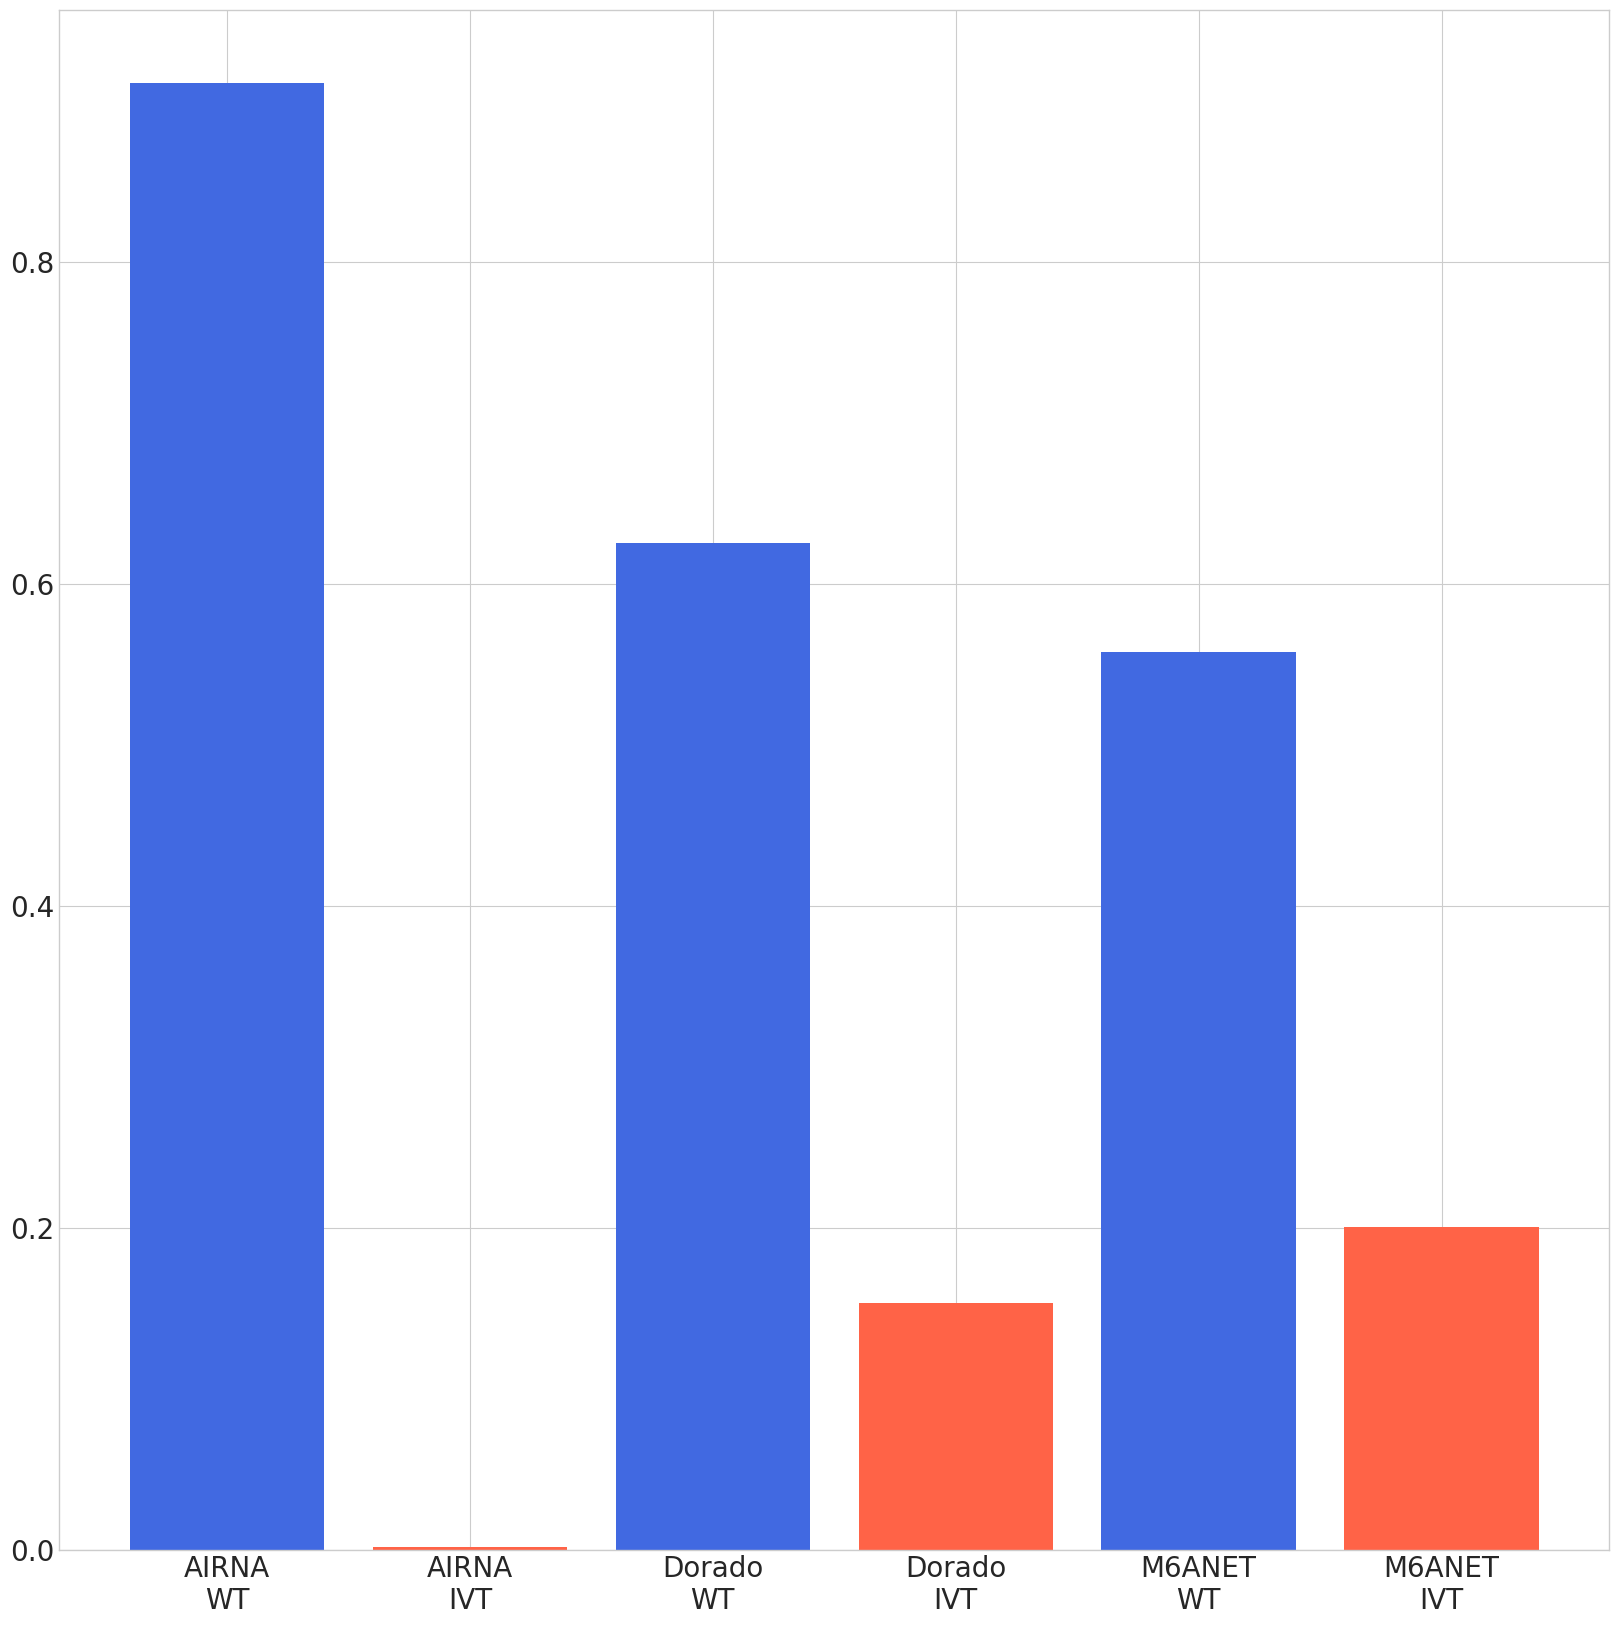

In [29]:
## Plot Bar chart
fig, ax = plt.subplots(1, 1, figsize=(20, 20))
plt.rcParams.update({'font.size': 32, 'lines.linewidth': 6})
wp = {'linewidth': 0, 'edgecolor':'white'}
colors = ['royalblue', 'tomato', ]

data = {}
x=np.sum(hek_df["pm6a"]>=airna_f1_thr)/mrna_count * 100
data["AIRNA\nWT"] = x
x=np.sum(ivt_df["pm6a"]>=airna_f1_thr)/ivt_count * 100
data["AIRNA\nIVT"] = x
x = np.sum(dorado_mrna["dom"]>=dorado_f1_thr)/mrna_count * 100
data["Dorado\nWT"] = x
x = np.sum(dorado_ivt["dom"]>=dorado_f1_thr)/ivt_count * 100
data["Dorado\nIVT"] = x
x = np.sum(df_m6anet_cell["pm6a"]>=m6anet_f1_thr)/mrna_count * 100
data["M6ANET\nWT"] = x
x = np.sum(df_m6anet_ivt["pm6a"]>=m6anet_f1_thr)/ivt_count * 100
data["M6ANET\nIVT"] = x
ax.bar(data.keys(), data.values(), color=colors)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/pie_ivt.pdf", format="pdf")
plt.show()

In [30]:
print(data)

{'AIRNA\nWT': 0.9108928107037532, 'AIRNA\nIVT': 0.00148691845557118, 'Dorado\nWT': 0.6253903744620555, 'Dorado\nIVT': 0.15345605366986648, 'M6ANET\nWT': 0.5577159347518877, 'M6ANET\nIVT': 0.2003698482068674}


In [35]:
print(np.sum(ivt_df["pm6a"]>=airna_f1_thr))
print(np.sum(dorado_ivt["dom"]>=dorado_f1_thr))
print(np.sum(df_m6anet_ivt["pm6a"]>=m6anet_f1_thr))

49
5057
6603


In [36]:
print(np.sum(hek_df["pm6a"]>=airna_f1_thr))

95552
